# Semana 1 y 2

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo oscuro de las gráficas
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

# Configuración adicional para un tema más oscuro
plt.rcParams['figure.facecolor'] = '#1a1a1a'
plt.rcParams['axes.facecolor'] = '#2b2b2b'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['text.color'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'

In [3]:
# Leer el dataset
data = pd.read_csv('data/Titanic - train.csv')

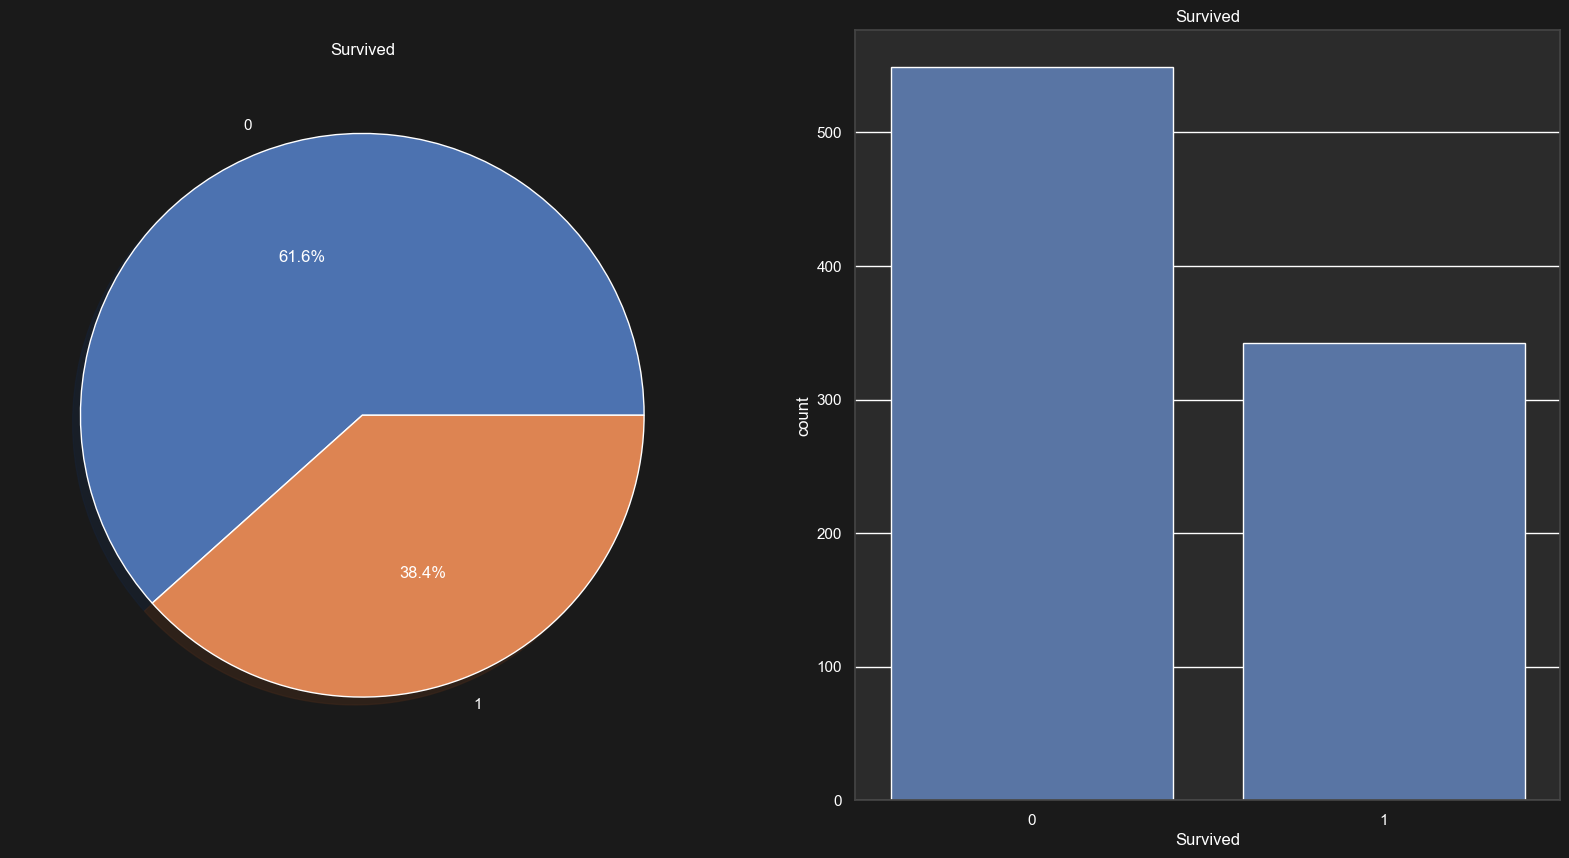

In [4]:
# El atributo 'Age', Cabin y Embarked tienen valores faltantes que debemos procesar
f, ax = plt.subplots(1, 2, figsize=(20, 10))
data['Survived'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Survived')
sns.countplot(data=data, x='Survived', ax=ax[1])
ax[1].set_title('Survived')
plt.show()

## Datos Categóricos

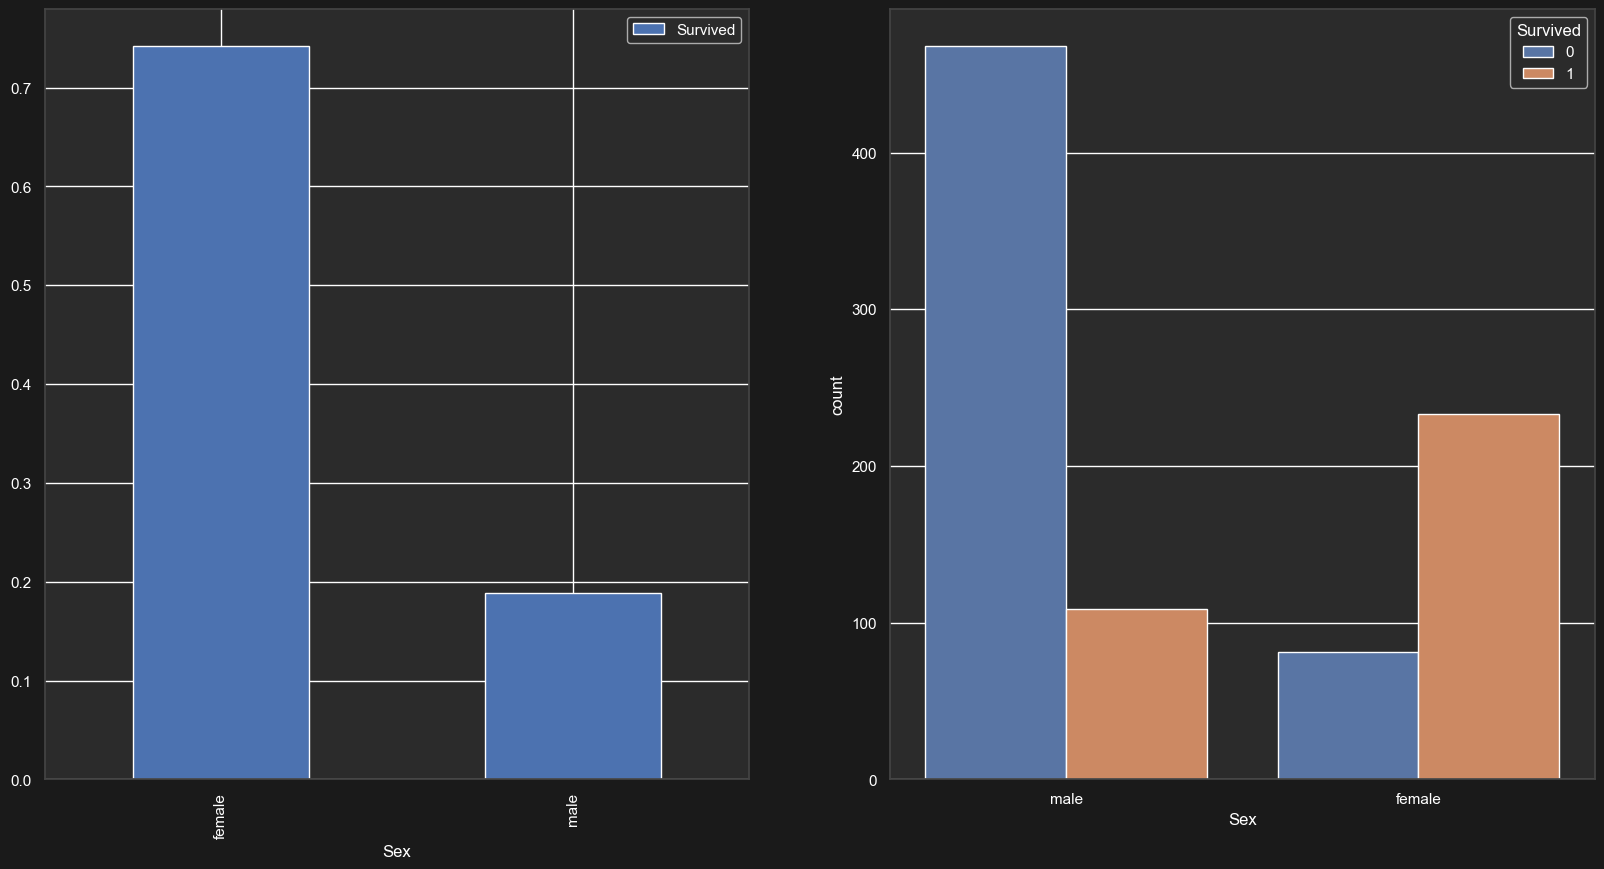

In [5]:
# Dato: "SEX", tiene influencia en la supervivencia
data.groupby(['Sex', 'Survived'])['Survived'].count()
f, ax = plt.subplots(1, 2, figsize=(20, 10))
data[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
sns.countplot(data=data, x='Sex', hue='Survived', ax=ax[1])
plt.show()

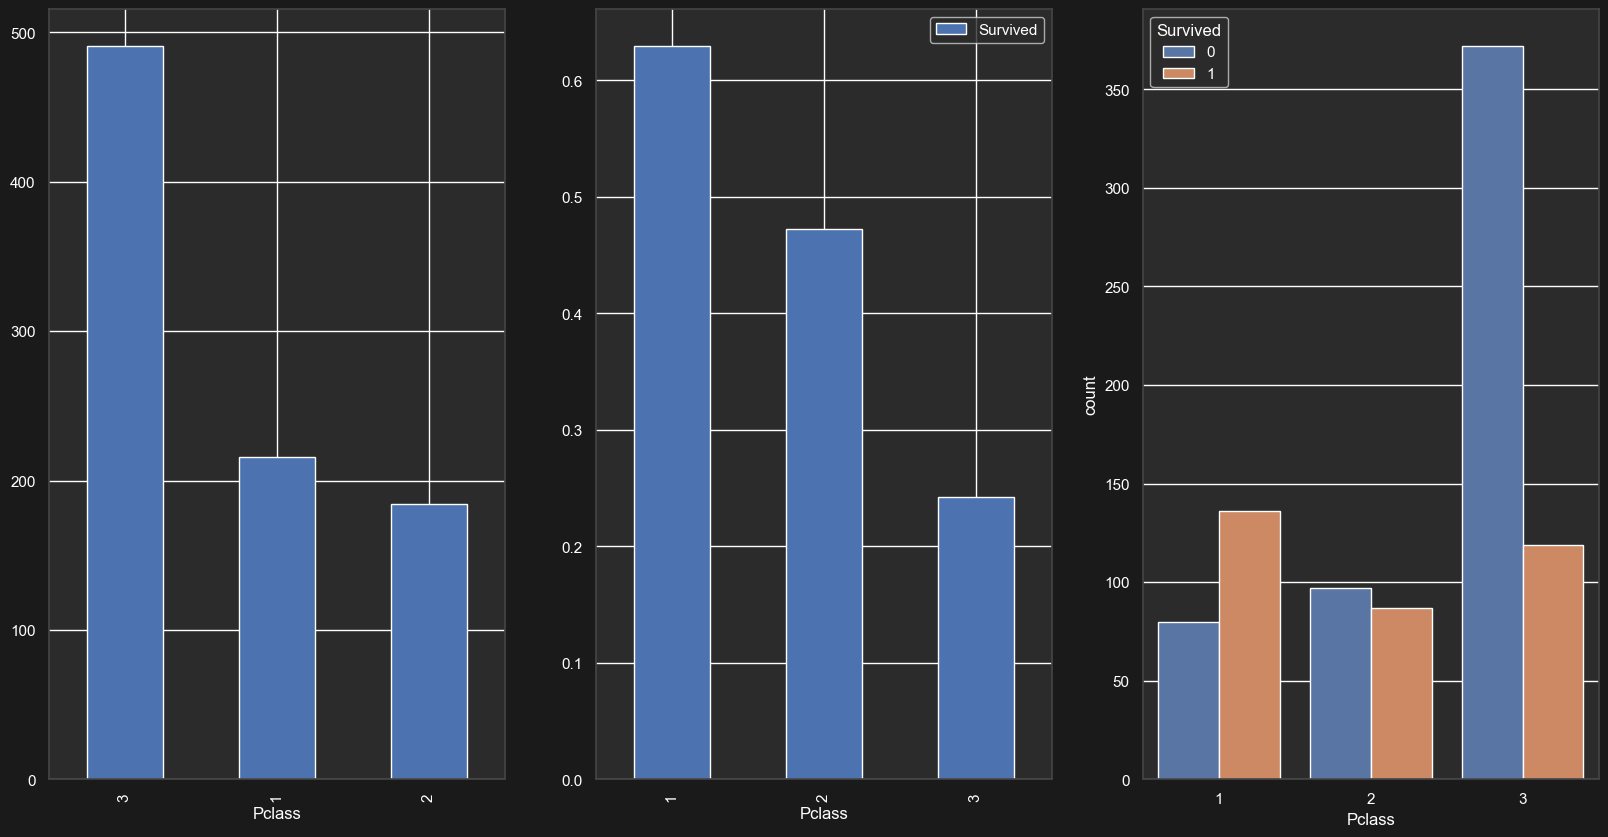

In [6]:
# Dato: "Pclass", tine influencia en la supervivencia
data.groupby(['Pclass', 'Survived'])['Survived'].count()
f, ax = plt.subplots(1, 3, figsize=(20, 10))
data['Pclass'].value_counts().plot.bar(ax=ax[0])
data[['Pclass', 'Survived']].groupby(['Pclass']).mean().plot.bar(ax=ax[1])
sns.countplot(data=data, x='Pclass', hue='Survived', ax=ax[2])
plt.show()

# Datos Ordinales

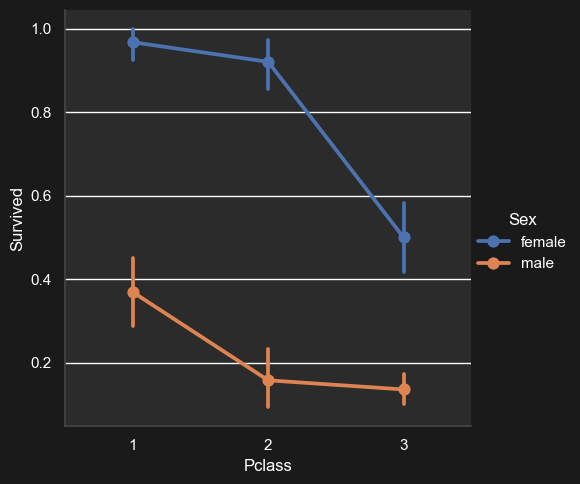

In [7]:
sns.catplot(data=data, x='Pclass', y='Survived', hue='Sex', kind='point')

# Datos Continuos

0.42 años
29.69911764705882 años
80.0 años


<Axes: xlabel='Sex', ylabel='Age'>

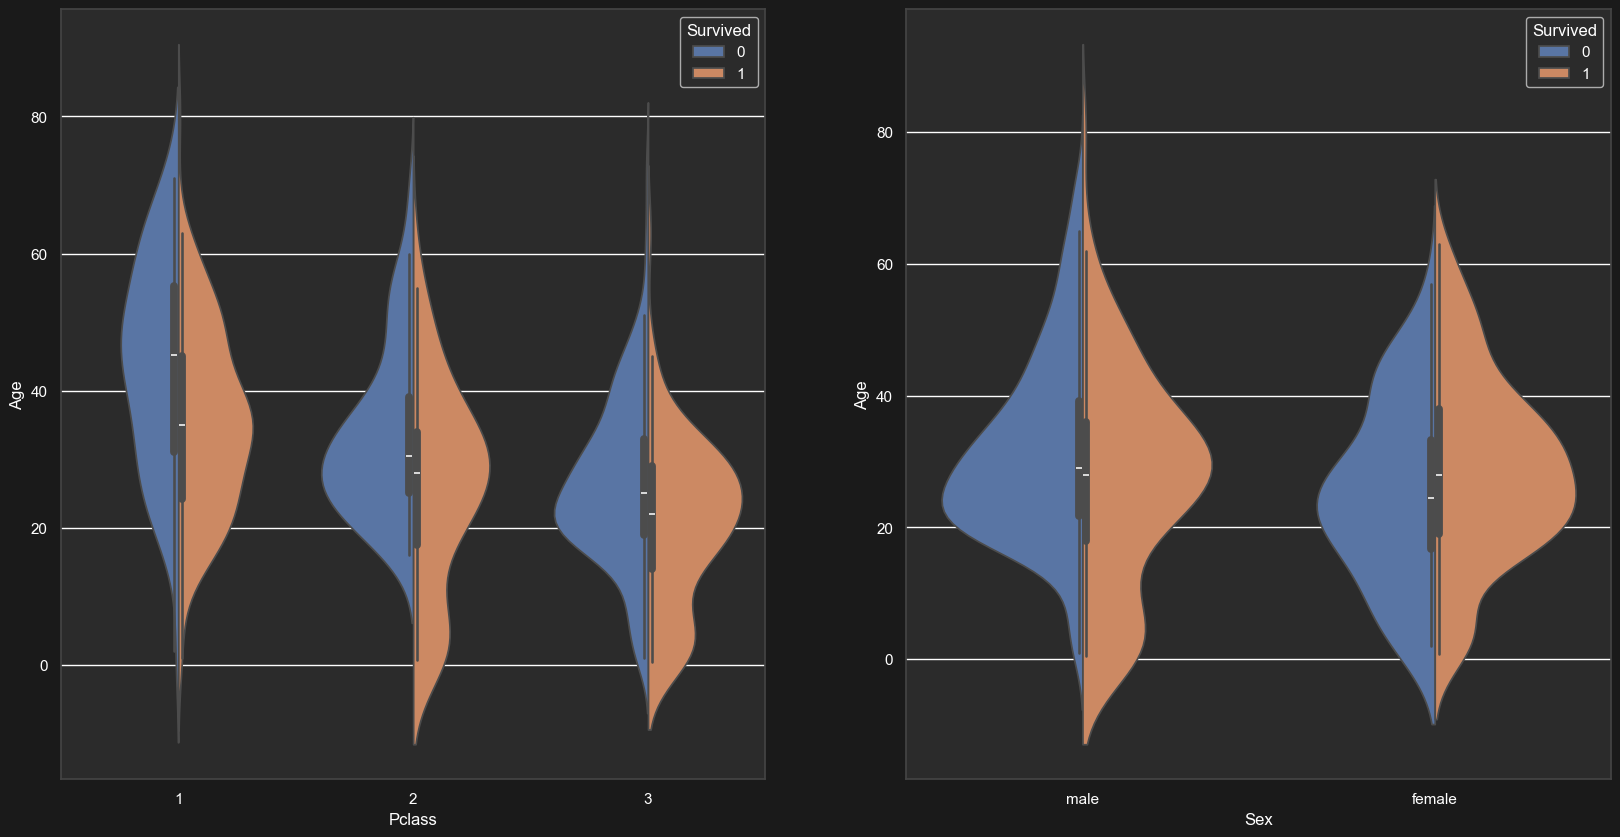

In [8]:
# Dato: "Age"
print(f'{data['Age'].min()} años')
print(f'{data['Age'].mean()} años')
print(f'{data['Age'].max()} años')

f, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.violinplot(data=data, x='Pclass', y='Age', hue='Survived', split=True, ax=ax[0])
sns.violinplot(data=data, x='Sex', y='Age', hue='Survived', split=True, ax=ax[1]) 

### Manejar los datos faltantes para la edad (**Age**)

Se va a extraer los **prefijos** de cada uno de los nombres y en base a estos se va a imputar un estimado para 
los datos de edad faltantes. En este caso el valor estimado sera el valor del promedio de cada grupo.

In [ ]:
prefixes = data['Name'].str.extract(r'([A-Za-z]+)\.')[0]
data['Prefix'] = prefixes

pd.crosstab(data['Prefix'], data['Sex'])

Sex,female,male
Prefix,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


#### ¿Que es crosstab?
**crosstab** crea una **tabla de frecuencias** que muestra la intersección entre dos variables categóricas. 
En este caso, nos muestra cuántas personas hay para cada combinación de Prefix (título) y Sex (género). 

Es útil para ver patrones de relación entre dos variables categóricas en forma de tabla.

In [14]:
# Se va a simplificar el número de prefijos, renombrando aquellos que no son muy comunes o tienen una frecuencia baja
# en base al contexto de su prefijo se le asignará uno nuevo dentro de las categorías 'Mr', 'Miss', 'Mrs' u 'Other'
data['Prefix'] = data['Prefix'].replace(
    ['Capt', 'Col', 'Countess', 'Don', 'Jonkheer', 'Lady', 'Major', 'Mlle', 'Mme', 'Ms', 'Rev', 'Sir', 'Dr'],
    ['Mr', 'Mr', 'Other', 'Mr', 'Other', 'Other', 'Mr', 'Miss', 'Mrs', 'Mrs', 'Mr', 'Mr', 'Mr'],
)

data.groupby('Prefix')['Age'].mean()

Prefix
Master     4.574167
Miss      21.804054
Mr        33.010791
Mrs       35.718182
Other     39.666667
Name: Age, dtype: float64

In [16]:
data.loc[(data['Age'].isnull()) & (data['Prefix'] == 'Master'), 'Age'] = 4.57
data.loc[(data['Age'].isnull()) & (data['Prefix'] == 'Miss'), 'Age'] = 21.80
data.loc[(data['Age'].isnull()) & (data['Prefix'] == 'Mr'), 'Age'] = 33.02
data.loc[(data['Age'].isnull()) & (data['Prefix'] == 'Mrs'), 'Age'] = 35.80
data.isnull().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age            False
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
Prefix         False
dtype: bool